# Exploratory Data Analysis 

**Sumber Data:**
* Dataset Utama: Data Science Job Postings & Skills (2024 - Kaggle) & Jobstreet Indonesia (Scraping).
* Dataset Sekunder A: Job Descriptions 2025 – Tech & Non-Tech Roles (Kaggle).
* Dataset Sekunder B: Software Engineer Job Postings [LinkedIn] (Kaggle).

**Problem Statement**
Banyak pencari kerja di bidang teknologi, baik fresh graduate maupun profesional yang ingin beralih karier, masih kesulitan memahami keterampilan apa yang belum memenuhi kebutuhan industri untuk posisi yang dituju. Melalui proyek ini, dikembangkan sistem analisis kesenjangan keterampilan berbasis NLP yang mampu memberikan rekomendasi secara data-driven dan spesifik sesuai profesi di bidang teknologi.

Adapun sistem ini dibangun bedasarkan analisis data lowongan kerja publik dari linkedin dan jobstreet dan dirancang sebagai alat bantu ekxplorasi mandiri, bukan sebagai penjamin keberhasilan rekrutmen. Skor yang ditampilkan merupakan estimasi berbasis pola skill dari ribuan job posting sesuai dengan dataset yang kami gunakan, dan tidak 100% mencerminkan seluruh faktor penilaian rekrutmen nyata seperti pengalaman kerja, soft skills, dan kebijakan internal perusahaan. Gunakan hasil analisis ini sebgai panduan awal untuk mengidentifikasi area pengembangan diri, bukan sebagai tolak ukur mutlak kelayakan melamar pekerjaan yang anda inginkan.

# Business Questions

1. Skill teknologi apa saja yang paling banyak diminta di industri saat ini?
2. Bagaimana perbedaan skill yang dibutuhkan antar 7 kategori profesi?
3. Skill apa saja yang paling sering diminta bersamaan dalam satu job posting?
4. Bagaimana distribusi data per role dan per sumber dataset?
5. Apakah ada perbedaan skill demand antara pasar global vs Indonesia?
6. Berapa rata-rata jumlah skill yang dibutuhkan per profesi? 
   

# Import Libraries

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from collections import Counter
from itertools import combinations
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 80)

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'sans-serif'
sns.set_theme(style='whitegrid', palette='muted')

# Warna konsisten per role — dipakai di SEMUA chart
ROLE_COLORS = {
    'Data Engineer':                '#2E75B6',
    'Data Analyst':                 '#4CAF50',
    'Backend Developer':            '#E07B39',
    'AI / Machine Learning Engineer':'#8172B2',
    'Data Scientist':               '#C44E52',
    'Fullstack Developer':          '#CCB974',
    'Frontend Developer':           '#64B5CD',
}

ROLES_ORDER = [
    'Data Engineer', 'Data Analyst', 'Backend Developer',
    'AI / Machine Learning Engineer', 'Data Scientist',
    'Fullstack Developer', 'Frontend Developer'
]

print('Libraries loaded! Siap analisis.')

Libraries loaded! Siap analisis.


# load data

In [18]:
# fix dataset 
df = pd.read_csv('Bismillah_fix_dataset.csv')
df.head()

,job_title,job_skills,cleaned_skills,job_category
0,Senior Machine Learning Engineer,"Machine Learning, Programming, Python, Scala, Java, Data Engineering, Distri...","ai, java, machine learning, python, pytorch, spark, tensorflow",AI / Machine Learning Engineer
1,"Principal Software Engineer, ML Accelerators","C++, Python, PyTorch, TensorFlow, MXNet, CUDA, OpenCL, OpenVX, Halide, SIMD ...","c++, computer vision, deep learning, linux, python, pytorch, tensorflow",Backend Developer
2,Lead Data Engineer,"Java, Scala, Python, RDBMS, NoSQL, Redshift, Snowflake, Unit testing, Agile ...","agile, aws, azure, cassandra, google cloud, hadoop, hive, java, kafka, linux...",Data Engineer
3,Senior Data Engineer,"Data Warehouse (DW), Extract/Transform/Load (ETL), Oracle, VPD, MuleSoft, Cl...","ai, apache, data warehouse, etl, excel, hadoop, java, oracle, pl/sql, python...",Data Engineer
4,"Manager, Cyber Risk & Analysis (Machine Learning)","Machine Learning, Generative AI, Cloudbased services, Risk management, Proje...","ai, cism, machine learning",AI / Machine Learning Engineer


In [19]:
print('DISTRIBUSI 7 ROLE FINAL')
role_dist = df['job_category'].value_counts()
print(role_dist.to_string())
print(f'\nTotal role unik : {df["job_category"].nunique()}')
print(f'Total baris     : {len(df):,}')

DISTRIBUSI 7 ROLE FINAL
job_category
Data Engineer                     2486
Data Analyst                      1807
Backend Developer                 1206
AI / Machine Learning Engineer    1032
Data Scientist                     948
Fullstack Developer                880
Frontend Developer                 285

Total role unik : 7
Total baris     : 8,644


# helper functions

In [20]:
def parse_skills(skill_str):
    """Ubah string 'python, sql, docker' → list ['python', 'sql', 'docker']."""
    if pd.isna(skill_str) or str(skill_str).strip() == '':
        return []
    return [s.strip().lower() for s in str(skill_str).split(',') if s.strip()]

def get_skill_counts(df_subset, col='cleaned_skills', top_n=20):
    """Hitung frekuensi skill dari kolom skill."""
    all_skills = []
    for s in df_subset[col].dropna():
        all_skills.extend(parse_skills(s))
    counter = Counter(all_skills)
    return pd.DataFrame(counter.most_common(top_n), columns=['skill', 'count'])

def plot_top_skills(df_counts, title, color='#2E75B6', top_n=15, ax=None):
    """Horizontal bar chart top skills."""
    data = df_counts.head(top_n).sort_values('count')
    if ax is None:
        fig, ax = plt.subplots(figsize=(9, top_n * 0.42 + 1))
    bars = ax.barh(data['skill'], data['count'], color=color, edgecolor='white', linewidth=0.5)
    ax.bar_label(bars, padding=4, fontsize=8.5, color='#333')
    ax.set_title(title, fontsize=11, fontweight='bold', pad=10)
    ax.set_xlabel('Jumlah Job Posting')
    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(axis='y', labelsize=8.5)
    return ax

# Hitung semua skill flat untuk referensi global
all_skills_flat = []
for s in df['cleaned_skills'].dropna():
    all_skills_flat.extend(parse_skills(s))

skill_freq_global = Counter(all_skills_flat)
total_unique_skills = len(skill_freq_global)

print(f'Total skill unik di seluruh dataset : {total_unique_skills:,}')
print(f'Total kemunculan skill (semua posting): {sum(skill_freq_global.values()):,}')
print('Helper functions ready!')

Total skill unik di seluruh dataset : 6,820
Total kemunculan skill (semua posting): 79,193
Helper functions ready!


# pertanyaan bisnis 1: 
**Skill teknologi apa saja yang paling banyak diminta di industri saat ini?**

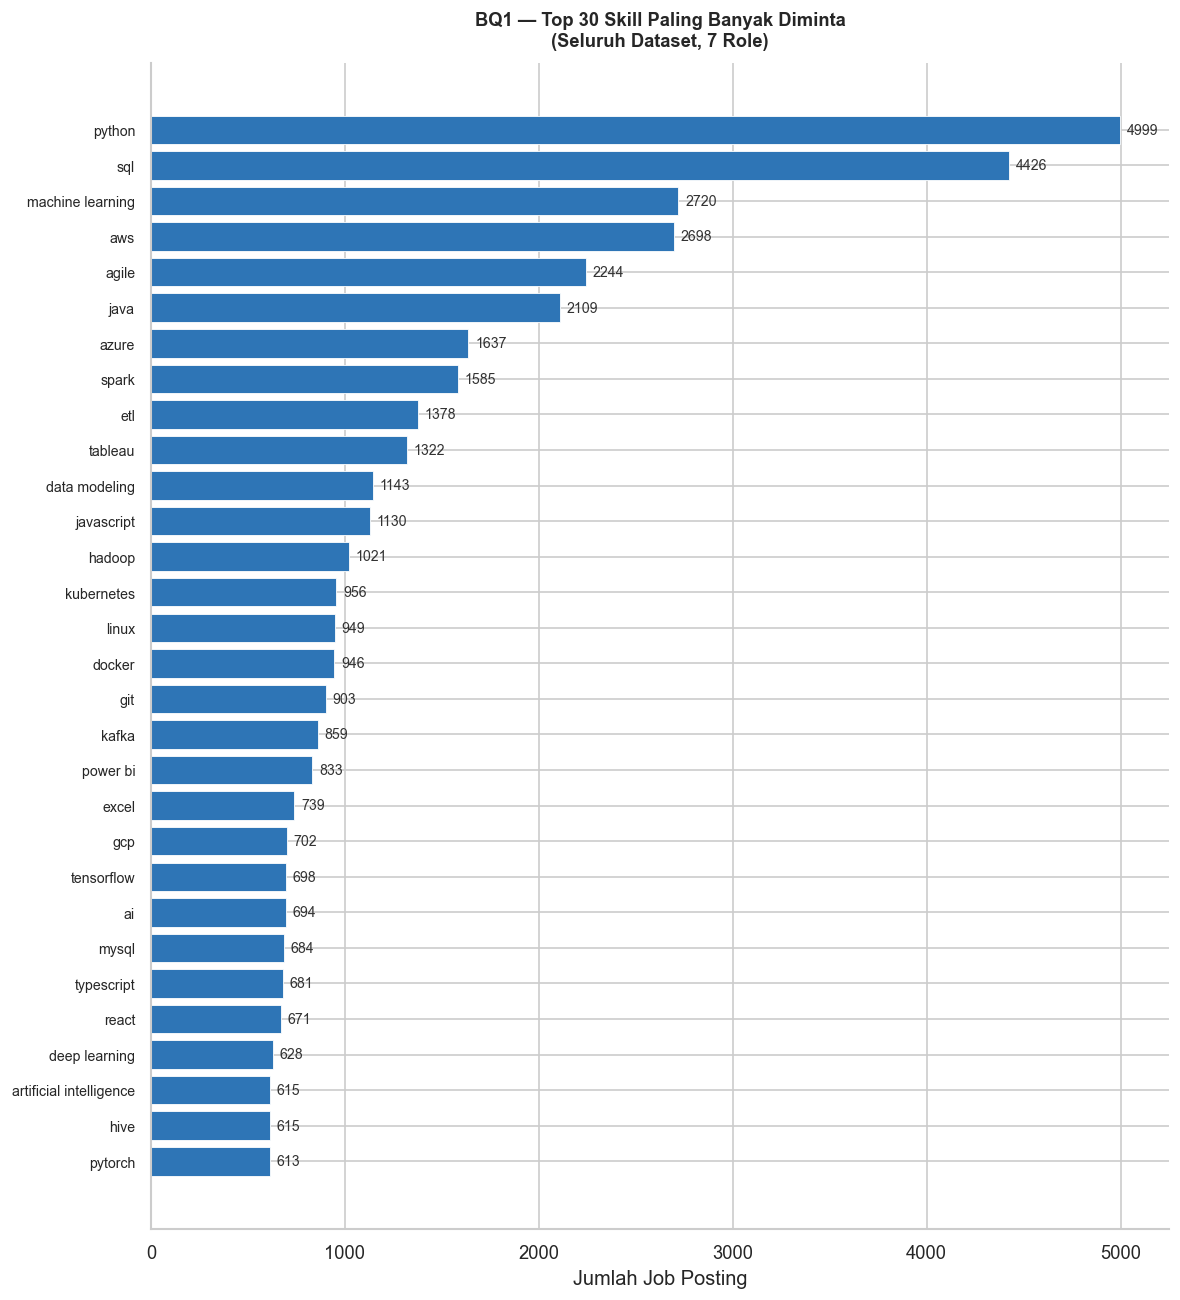

Top 30 Skill:
                  skill  count
                 python   4999
                    sql   4426
       machine learning   2720
                    aws   2698
                  agile   2244
                   java   2109
                  azure   1637
                  spark   1585
                    etl   1378
                tableau   1322
          data modeling   1143
             javascript   1130
                 hadoop   1021
             kubernetes    956
                  linux    949
                 docker    946
                    git    903
                  kafka    859
               power bi    833
                  excel    739
                    gcp    702
             tensorflow    698
                     ai    694
                  mysql    684
             typescript    681
                  react    671
          deep learning    628
                   hive    615
artificial intelligence    615
                pytorch    613


In [21]:
# ── 4.1 Top 30 skill overall ─────────────────────────────────────────────────
top30 = pd.DataFrame(skill_freq_global.most_common(30), columns=['skill', 'count'])

fig, ax = plt.subplots(figsize=(10, 11))
plot_top_skills(top30, 'BQ1 — Top 30 Skill Paling Banyak Diminta\n(Seluruh Dataset, 7 Role)',
                color='#2E75B6', top_n=30, ax=ax)
plt.tight_layout()
plt.savefig('plot_bq1_top30_skills.png', bbox_inches='tight', dpi=150)
plt.show()

print('Top 30 Skill:')
print(top30.to_string(index=False))

**Insight Analisis Permintaan Keterampilan Makro (Global Tech Demand):**

Dominasi Data-Driven Skills: Berdasarkan total kemunculan 79.193 skill di seluruh lowongan, teknologi pengelolaan data (seperti SQL dan Python) menempati posisi teratas industri teknologi secara makro. Hal ini menunjukkan bahwa pemahaman fundamental data tidak lagi eksklusif untuk ilmuwan data, melainkan menjadi kebutuhan universal di era transformasi digital.

Kombinasi Rekayasa Perangkat Lunak: Hadirnya bahasa pemrograman serbaguna seperti Python dan Java dalam top list global membuktikan tingginya kebutuhan akan infrastruktur aplikasi yang kokoh, baik untuk kebutuhan skalabilitas sistem backend maupun integrasi model kecerdasan buatan (AI/ML).

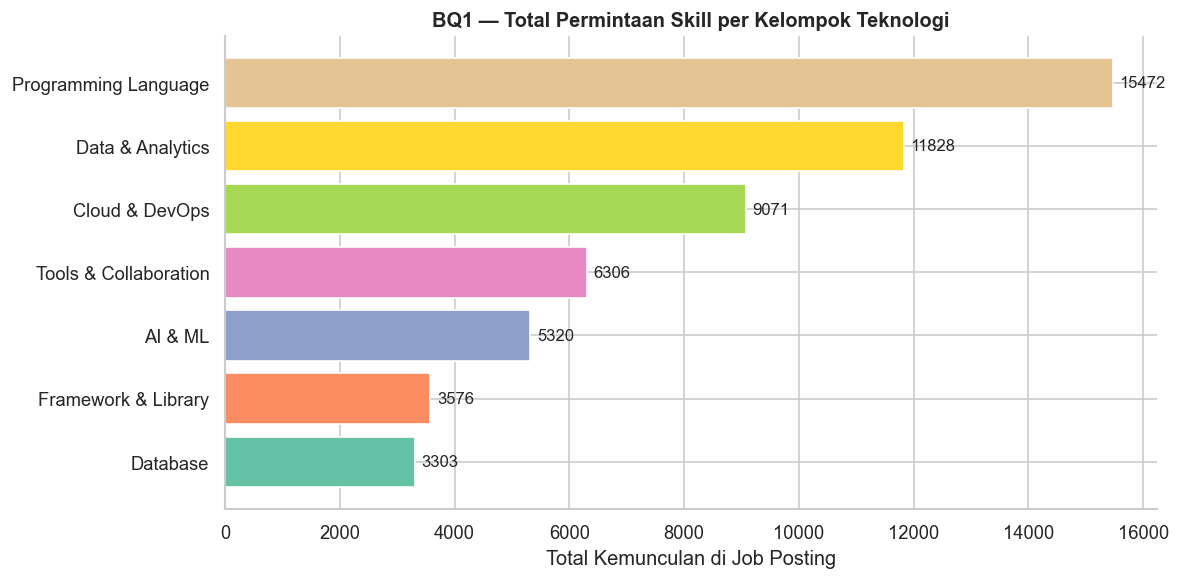

In [22]:
# ── 4.2 Skill per kelompok teknologi ─────────────────────────────────────────
skill_groups = {
    'Programming Language': [
        'python', 'java', 'javascript', 'typescript', 'c++', 'c#', 'php',
        'go', 'golang', 'ruby', 'swift', 'kotlin', 'dart', 'sql', 'bash'
    ],
    'Framework & Library': [
        'react', 'react.js', 'node.js', 'django', 'flask', 'fastapi',
        'spring boot', 'laravel', 'vue.js', 'angular', 'next.js', 'flutter',
        'pytorch', 'tensorflow', 'scikit-learn', 'langchain'
    ],
    'Database': [
        'mysql', 'postgresql', 'mongodb', 'redis', 'elasticsearch',
        'sql server', 'oracle', 'cassandra', 'mariadb'
    ],
    'Cloud & DevOps': [
        'aws', 'azure', 'gcp', 'docker', 'kubernetes', 'ci/cd',
        'terraform', 'jenkins', 'github actions', 'linux'
    ],
    'AI & ML': [
        'machine learning', 'deep learning', 'nlp', 'computer vision',
        'llm', 'pytorch', 'tensorflow', 'scikit-learn', 'rag', 'prompt engineering'
    ],
    'Data & Analytics': [
        'sql', 'power bi', 'tableau', 'excel', 'etl', 'spark', 'hadoop',
        'airflow', 'dbt', 'data warehouse', 'looker'
    ],
    'Tools & Collaboration': [
        'git', 'github', 'jira', 'figma', 'postman', 'rest api',
        'agile', 'scrum', 'docker', 'linux'
    ]
}

group_totals = {}
for group, skills in skill_groups.items():
    group_totals[group] = sum(skill_freq_global.get(s, 0) for s in skills)

group_df = pd.DataFrame(list(group_totals.items()), columns=['group', 'total'])
group_df = group_df.sort_values('total', ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(group_df['group'], group_df['total'],
               color=sns.color_palette('Set2', len(group_df)), edgecolor='white')
ax.bar_label(bars, fmt='%d', padding=4, fontsize=10)
ax.set_title('BQ1 — Total Permintaan Skill per Kelompok Teknologi', fontsize=12, fontweight='bold')
ax.set_xlabel('Total Kemunculan di Job Posting')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('plot_bq1_skill_groups.png', bbox_inches='tight', dpi=150)
plt.show()

# pertanyaan bisnis 2:
**Bagaimana perbedaan skill yang dibutuhkan antar 7 kategori profesi?**

In [25]:
# Top 10 skill per role
skill_per_role = {}
for role in ROLES_ORDER:
    subset = df[df['job_category'] == role]
    skill_per_role[role] = get_skill_counts(subset, top_n=10)
    print(f'\n# {role} (n={len(subset):,}) #')
    print(skill_per_role[role].to_string(index=False))


# Data Engineer (n=2,486) #
        skill  count
          sql   1663
       python   1555
          aws   1105
        spark    998
        agile    929
        azure    878
          etl    863
         java    776
data modeling    702
       hadoop    700

# Data Analyst (n=1,807) #
           skill  count
             sql   1277
          python    887
         tableau    792
           excel    642
        power bi    561
machine learning    303
   data modeling    285
             etl    268
           agile    235
      sql server    149

# Backend Developer (n=1,206) #
     skill  count
    python    494
      java    444
       aws    340
       git    295
       sql    292
kubernetes    267
     agile    264
javascript    250
    docker    246
       c++    200

# AI / Machine Learning Engineer (n=1,032) #
           skill  count
machine learning    909
          python    718
      tensorflow    480
   deep learning    440
         pytorch    424
             aws    341
   

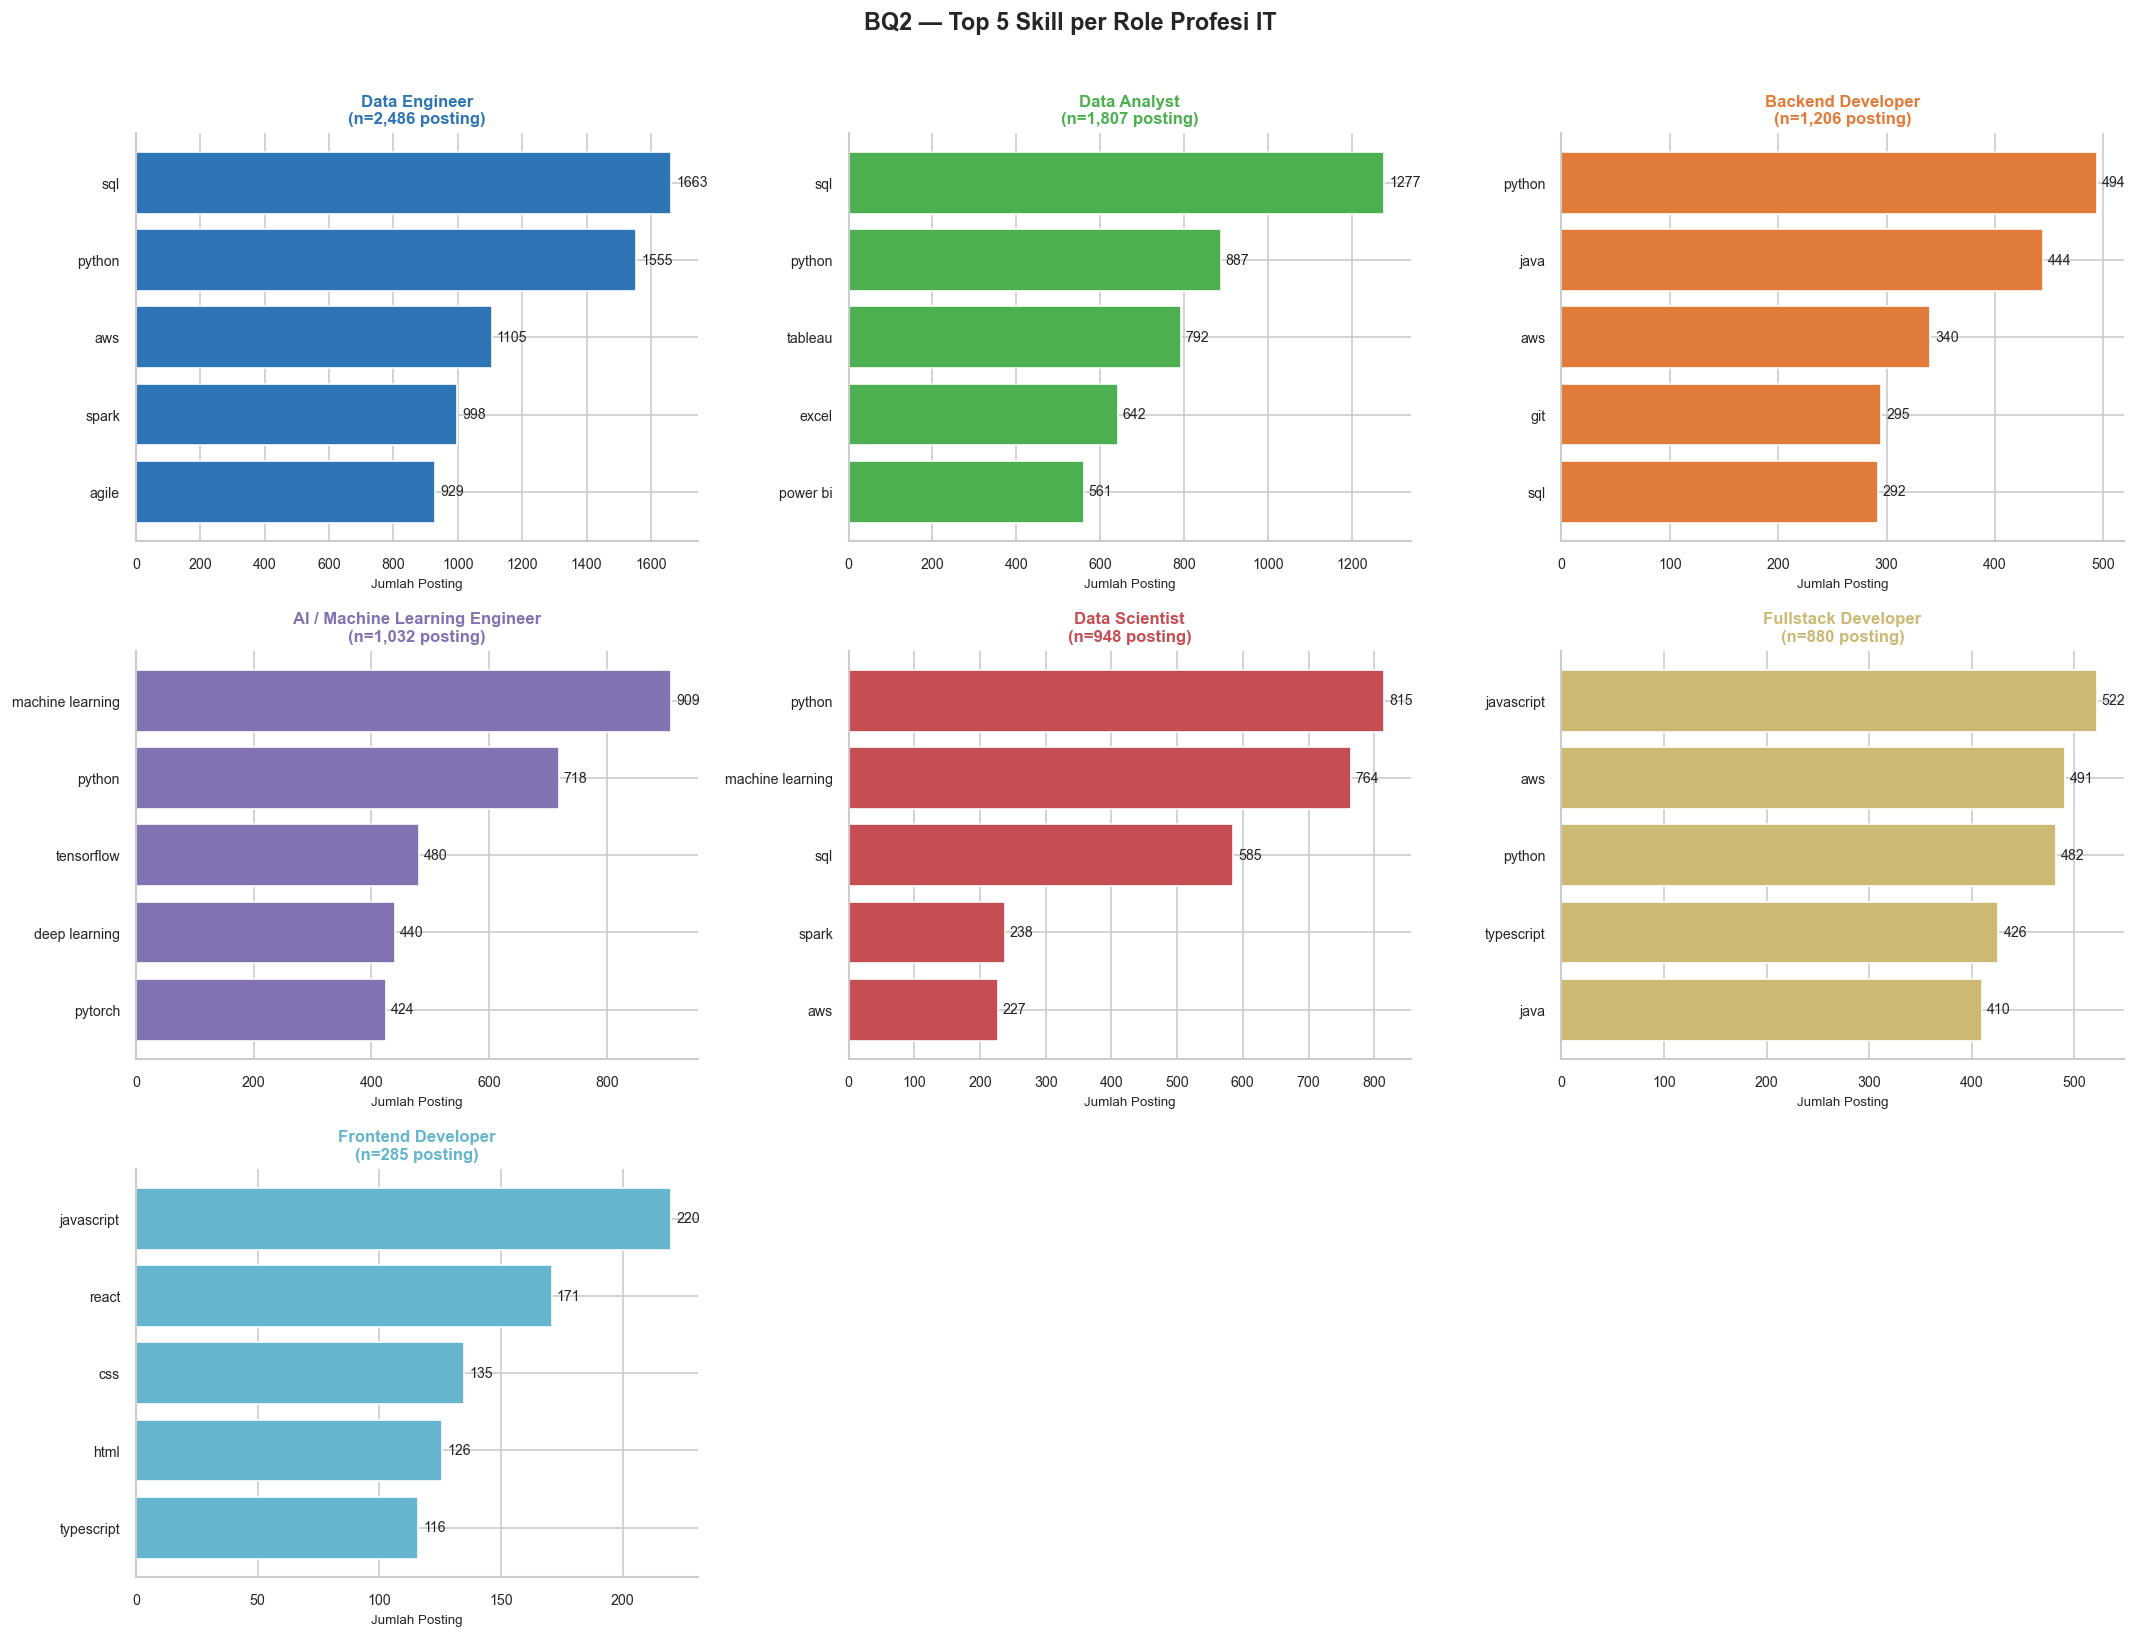

In [27]:
# ── Grid: Top 5 skill per role ────────────────────────────────────────────────
n_roles = len(ROLES_ORDER)
n_cols = 3
n_rows = (n_roles + n_cols - 1) // n_cols  # = 3

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4.5))
axes = axes.flatten()

for i, role in enumerate(ROLES_ORDER):
    ax = axes[i]
    top5 = skill_per_role[role].head(5).sort_values('count')
    color = ROLE_COLORS.get(role, '#999')
    n = len(df[df['job_category'] == role])
    bars = ax.barh(top5['skill'], top5['count'], color=color, edgecolor='white')
    ax.bar_label(bars, padding=3, fontsize=8.5)
    ax.set_title(f'{role}\n(n={n:,} posting)', fontsize=10, fontweight='bold', color=color)
    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(labelsize=8.5)
    ax.set_xlabel('Jumlah Posting', fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('BQ2 — Top 5 Skill per Role Profesi IT', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plot_bq2_top5_per_role.png', bbox_inches='tight', dpi=150)
plt.show()

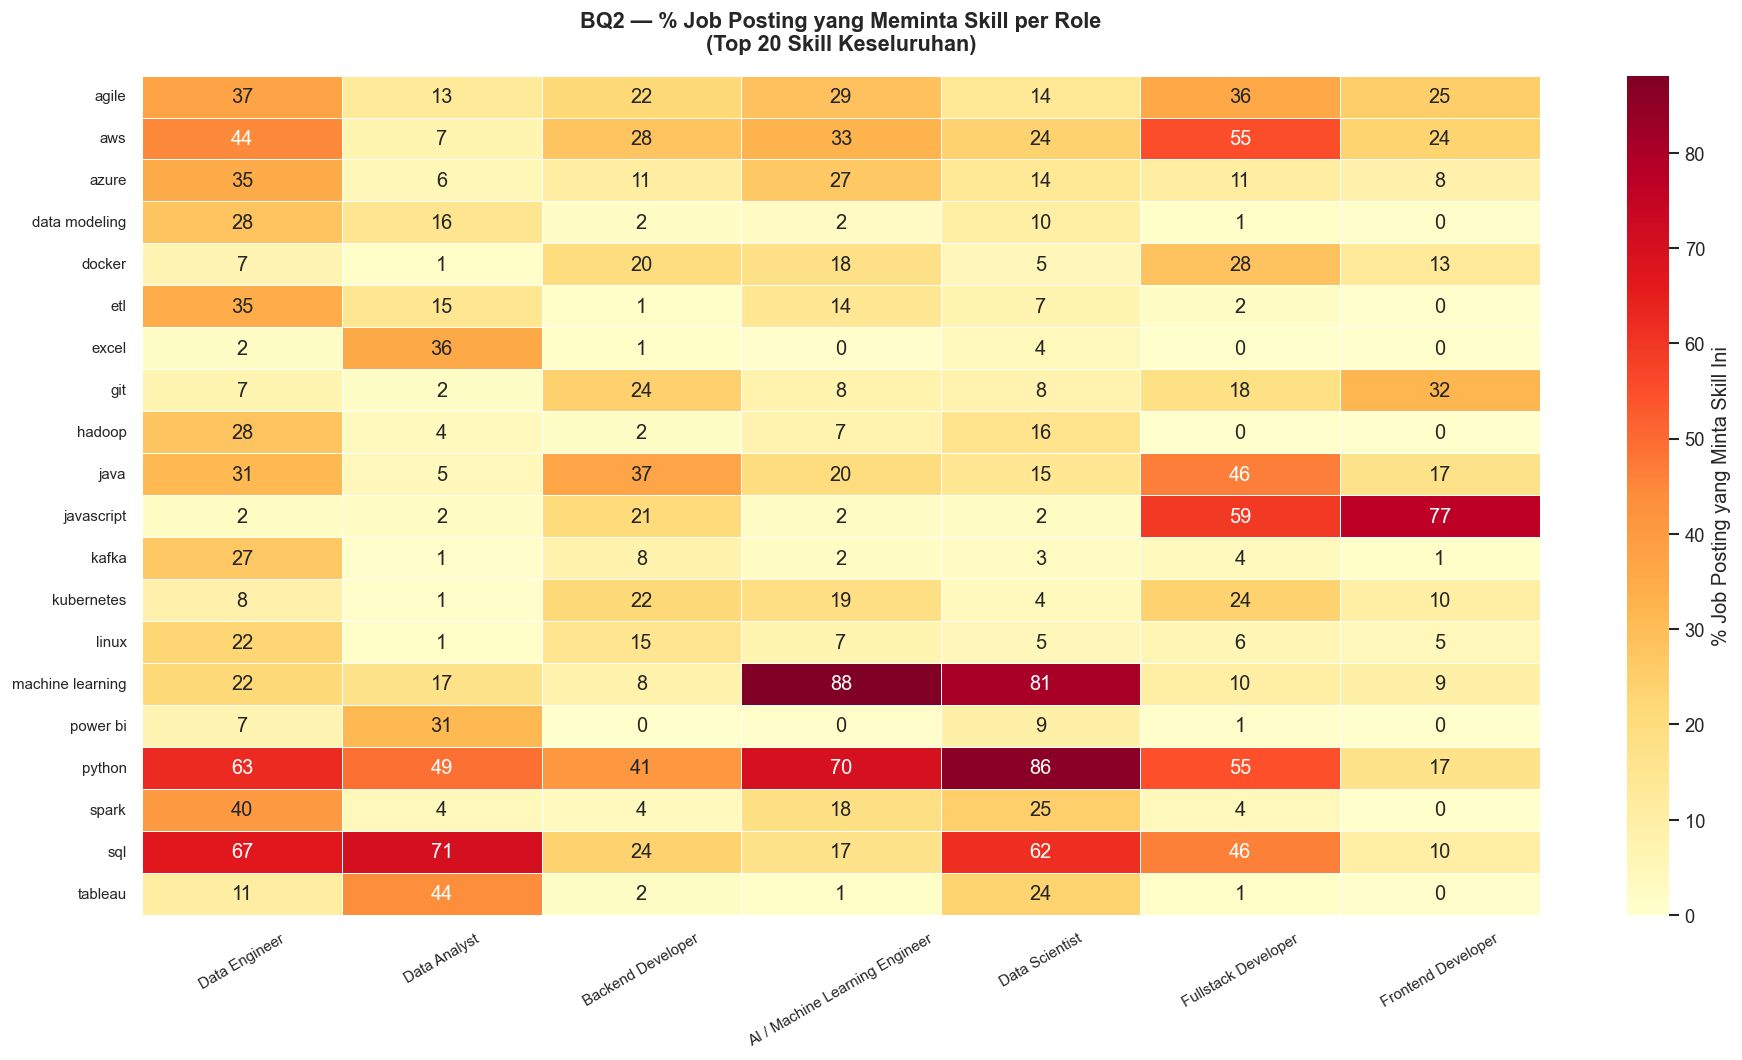

In [28]:
# ── Heatmap: % job posting yang minta skill X per role ────────────────────────
top20_skills = [s for s, _ in skill_freq_global.most_common(20)]

heatmap_rows = []
for role in ROLES_ORDER:
    subset = df[df['job_category'] == role]
    total = len(subset)
    for skill in top20_skills:
        count = subset['cleaned_skills'].apply(
            lambda x: skill in parse_skills(x)
        ).sum()
        heatmap_rows.append({
            'role': role, 'skill': skill,
            'pct': round(count / total * 100, 1) if total > 0 else 0
        })

heatmap_df = pd.DataFrame(heatmap_rows).pivot(index='skill', columns='role', values='pct')
heatmap_df = heatmap_df[ROLES_ORDER].fillna(0)

fig, ax = plt.subplots(figsize=(16, 9))
sns.heatmap(
    heatmap_df, annot=True, fmt='.0f', cmap='YlOrRd',
    linewidths=0.4, linecolor='white',
    cbar_kws={'label': '% Job Posting yang Minta Skill Ini'},
    ax=ax
)
ax.set_title(
    'BQ2 — % Job Posting yang Meminta Skill per Role\n(Top 20 Skill Keseluruhan)',
    fontsize=13, fontweight='bold', pad=15
)
ax.set_xlabel('')
ax.set_ylabel('')
ax.tick_params(axis='x', rotation=30, labelsize=9)
ax.tick_params(axis='y', rotation=0, labelsize=9)
plt.tight_layout()
plt.savefig('plot_bq2_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()

In [29]:
# ── Export Knowledge Base → langsung dipakai AI Engineer ─────────────────────
kb_rows = []
for role, df_s in skill_per_role.items():
    for rank, (_, row) in enumerate(df_s.iterrows(), 1):
        if rank <= 3:
            tier = 'Critical'
        elif rank <= 6:
            tier = 'Important'
        else:
            tier = 'Supplementary'
        kb_rows.append({
            'job_category': role,
            'skill': row['skill'],
            'frequency': row['count'],
            'rank_in_role': rank,
            'tier': tier
        })

kb_df = pd.DataFrame(kb_rows)
kb_df.to_csv('knowledge_base_skills.csv', index=False)

print('Knowledge base berhasil disimpan ke knowledge_base_skills.csv!')
print(f'Total entri: {len(kb_df)}')
print(f'\nDistribusi tier:')
print(kb_df['tier'].value_counts().to_string())
print()
print('Preview per role:')
print(kb_df.groupby('job_category')['skill'].apply(list).to_string())

Knowledge base berhasil disimpan ke knowledge_base_skills.csv!
Total entri: 70

Distribusi tier:
tier
Supplementary    28
Critical         21
Important        21

Preview per role:
job_category
AI / Machine Learning Engineer    [machine learning, python, tensorflow, deep learning, pytorch, aws, ai, agil...
Backend Developer                       [python, java, aws, git, sql, kubernetes, agile, javascript, docker, c++]
Data Analyst                      [sql, python, tableau, excel, power bi, machine learning, data modeling, etl...
Data Engineer                           [sql, python, aws, spark, agile, azure, etl, java, data modeling, hadoop]
Data Scientist                    [python, machine learning, sql, spark, aws, tableau, artificial intelligence...
Frontend Developer                [javascript, react, css, html, typescript, git, angular, agile, aws, fronten...
Fullstack Developer                    [javascript, aws, python, typescript, java, sql, agile, react, go, docker]


# Pertanyaan Bisnis 3:
**Skill apa yang paling sering diminta bersamaan dalam satu job posting?**

In [30]:
# Bangun co-occurrence matrix dari top 20 skill
top20 = [s for s, _ in skill_freq_global.most_common(20)]
cooc = pd.DataFrame(0, index=top20, columns=top20)

for skill_str in df['cleaned_skills'].dropna():
    skills_in_post = [s for s in parse_skills(skill_str) if s in top20]
    for s1, s2 in combinations(skills_in_post, 2):
        cooc.loc[s1, s2] += 1
        cooc.loc[s2, s1] += 1

# Top 10 pasangan
pairs = []
for i, s1 in enumerate(top20):
    for j, s2 in enumerate(top20):
        if i < j:
            pairs.append({'skill_1': s1, 'skill_2': s2, 'co_count': cooc.loc[s1, s2]})
pairs_df = pd.DataFrame(pairs).sort_values('co_count', ascending=False)

print('Top 10 pasangan skill yang paling sering muncul bersamaan:')
print(pairs_df.head(10).to_string(index=False))

Top 10 pasangan skill yang paling sering muncul bersamaan:
skill_1          skill_2  co_count
 python              sql      3131
 python machine learning      2182
 python              aws      2075
 python             java      1703
 python            agile      1671
    sql              aws      1513
 python            spark      1430
    sql machine learning      1315
    sql            agile      1300
    aws            agile      1220


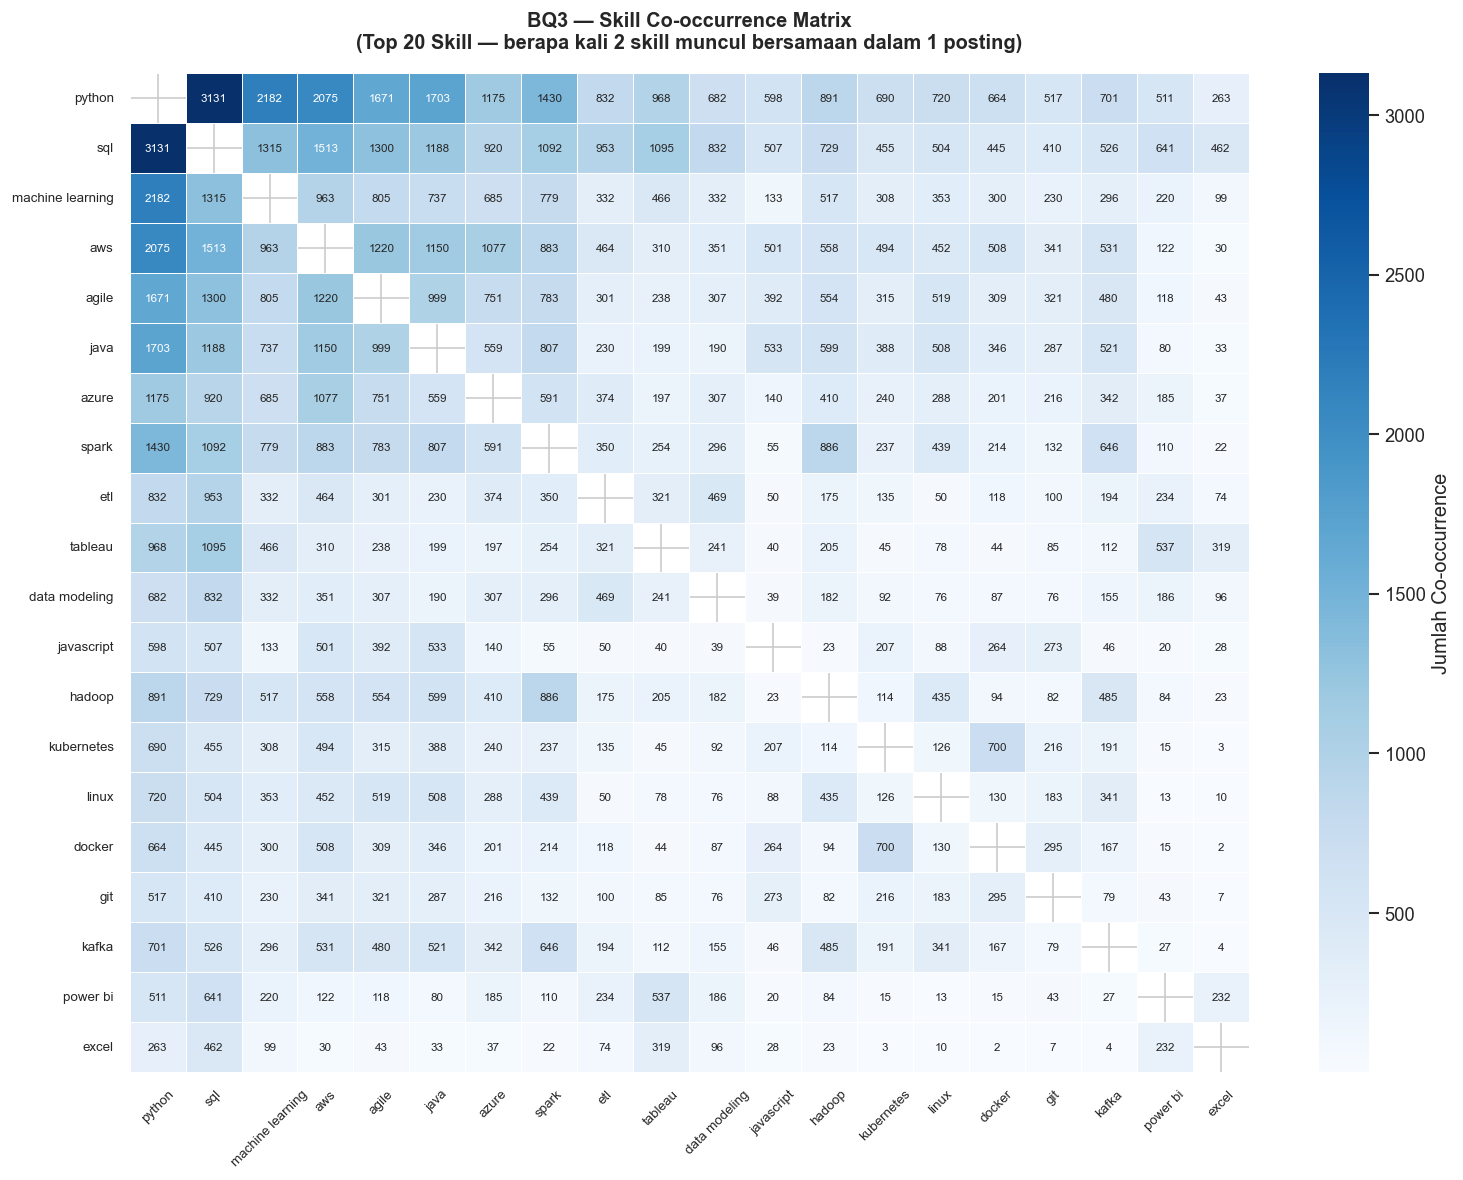

In [31]:
fig, ax = plt.subplots(figsize=(13, 10))
mask = np.eye(len(cooc), dtype=bool)
sns.heatmap(
    cooc, mask=mask, cmap='Blues',
    linewidths=0.3, linecolor='white',
    annot=True, fmt='d', annot_kws={'size': 7},
    cbar_kws={'label': 'Jumlah Co-occurrence'},
    ax=ax
)
ax.set_title(
    'BQ3 — Skill Co-occurrence Matrix\n(Top 20 Skill — berapa kali 2 skill muncul bersamaan dalam 1 posting)',
    fontsize=12, fontweight='bold', pad=15
)
ax.tick_params(axis='x', rotation=45, labelsize=8)
ax.tick_params(axis='y', rotation=0, labelsize=8)
plt.tight_layout()
plt.savefig('plot_bq3_cooccurrence.png', bbox_inches='tight', dpi=150)
plt.show()

# pertanyaan Bisnis 4:
**Bagaimana distribusi data per role dan seberapa representatif masing-masing role?**

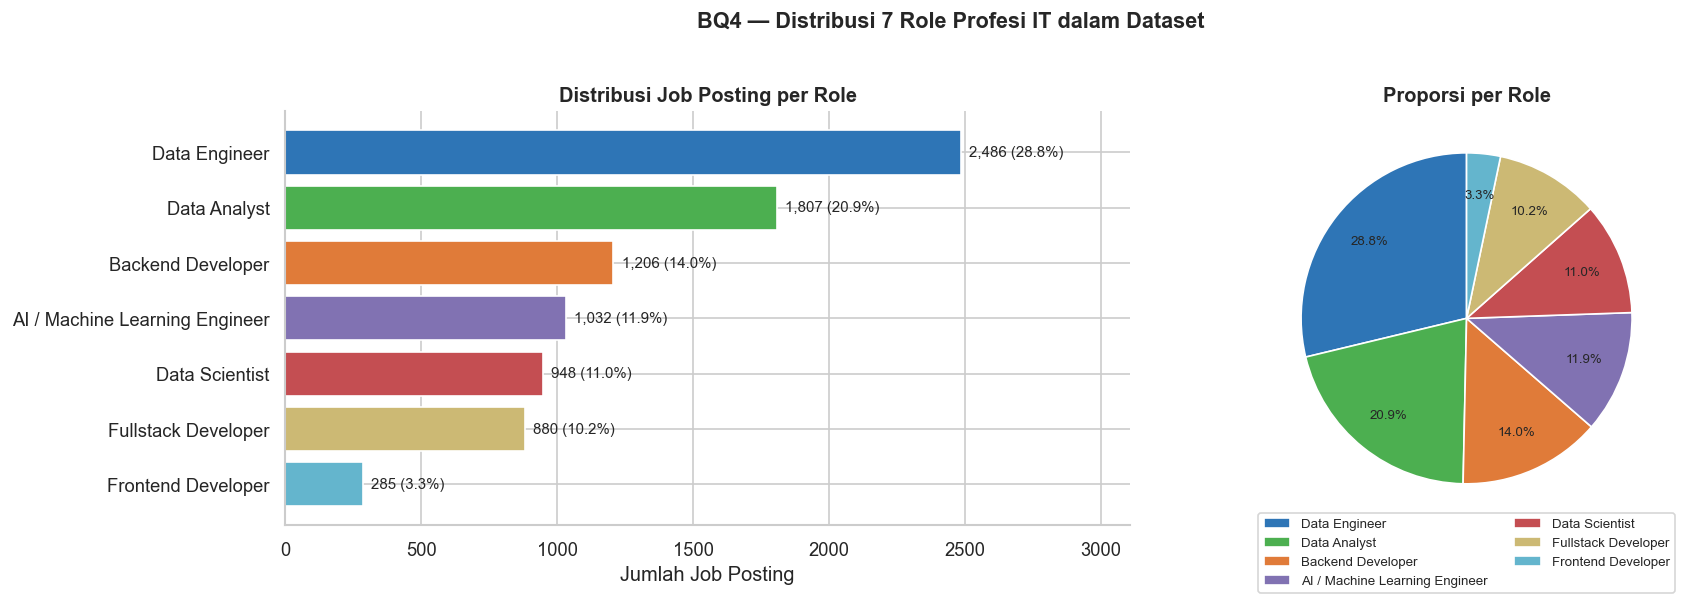

                  job_category  count  pct
                 Data Engineer   2486 28.8
                  Data Analyst   1807 20.9
             Backend Developer   1206 14.0
AI / Machine Learning Engineer   1032 11.9
                Data Scientist    948 11.0
           Fullstack Developer    880 10.2
            Frontend Developer    285  3.3


In [33]:
# ── 3.1 Distribusi per role ───────────────────────────────────────────────────
role_dist_df = df['job_category'].value_counts().reset_index()
role_dist_df.columns = ['job_category', 'count']
role_dist_df['pct'] = (role_dist_df['count'] / role_dist_df['count'].sum() * 100).round(1)
role_dist_df = role_dist_df.set_index('job_category').reindex(ROLES_ORDER).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Bar chart
colors = [ROLE_COLORS.get(r, '#999') for r in role_dist_df['job_category']]
bars = axes[0].barh(
    role_dist_df['job_category'][::-1],
    role_dist_df['count'][::-1],
    color=colors[::-1], edgecolor='white'
)
axes[0].bar_label(
    bars,
    labels=[f"{v:,} ({p}%)" for v, p in zip(role_dist_df['count'][::-1], role_dist_df['pct'][::-1])],
    padding=5, fontsize=9
)
axes[0].set_title('Distribusi Job Posting per Role', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Jumlah Job Posting')
axes[0].spines[['top', 'right']].set_visible(False)
axes[0].set_xlim(0, role_dist_df['count'].max() * 1.25)

# Pie chart
pie_colors = [ROLE_COLORS.get(r, '#999') for r in role_dist_df['job_category']]
wedges, texts, autotexts = axes[1].pie(
    role_dist_df['count'],
    labels=None,
    autopct='%1.1f%%',
    colors=pie_colors,
    startangle=90,
    pctdistance=0.75
)
for at in autotexts:
    at.set_fontsize(8)
axes[1].legend(
    wedges, role_dist_df['job_category'],
    loc='lower center', bbox_to_anchor=(0.5, -0.18),
    ncol=2, fontsize=8
)
axes[1].set_title('Proporsi per Role', fontsize=12, fontweight='bold')

plt.suptitle('BQ4 — Distribusi 7 Role Profesi IT dalam Dataset', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plot_bq4_distribusi_role.png', bbox_inches='tight', dpi=150)
plt.show()
print(role_dist_df.to_string(index=False))

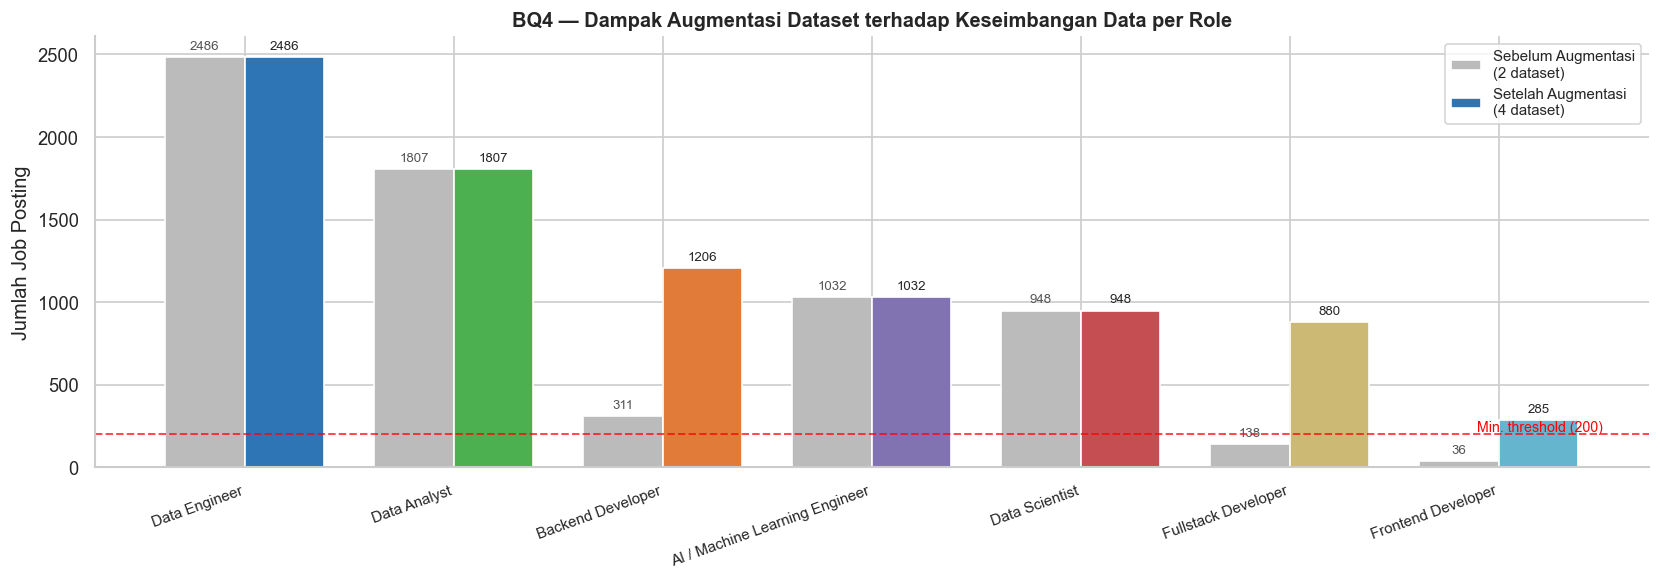

Insight: 3 role developer (Backend, Fullstack, Frontend) awalnya sangat minim data.
Augmentasi dari 2 dataset tambahan berhasil membawa semua role di atas threshold.


In [34]:
# ── 3.2 Konteks historis: kenapa 3 dataset? ───────────────────────────────────
# Simulasi distribusi SEBELUM augmentasi (hanya dari dataset 1 + Jobstreet)
before_aug = {
    'Data Engineer':                  2486,
    'Data Analyst':                   1807,
    'AI / Machine Learning Engineer': 1032,
    'Data Scientist':                  948,
    'Backend Developer':               311,
    'Fullstack Developer':             138,
    'Frontend Developer':               36,
}
after_aug = dict(zip(role_dist_df['job_category'], role_dist_df['count']))

roles = ROLES_ORDER
before_vals = [before_aug.get(r, 0) for r in roles]
after_vals  = [after_aug.get(r, 0) for r in roles]

x = np.arange(len(roles))
width = 0.38

fig, ax = plt.subplots(figsize=(14, 5))
bars1 = ax.bar(x - width/2, before_vals, width, label='Sebelum Augmentasi\n(2 dataset)', color='#BBBBBB', edgecolor='white')
bars2 = ax.bar(x + width/2, after_vals,  width, label='Setelah Augmentasi\n(4 dataset)', 
               color=[ROLE_COLORS.get(r, '#999') for r in roles], edgecolor='white')

ax.bar_label(bars1, fmt='%d', padding=3, fontsize=8, color='#555')
ax.bar_label(bars2, fmt='%d', padding=3, fontsize=8)

# Garis threshold minimum
ax.axhline(y=200, color='red', linestyle='--', linewidth=1.2, alpha=0.7)
ax.text(len(roles)-0.5, 220, 'Min. threshold (200)', color='red', fontsize=8.5, ha='right')

ax.set_xticks(x)
ax.set_xticklabels(roles, rotation=20, ha='right', fontsize=9)
ax.set_ylabel('Jumlah Job Posting')
ax.set_title('BQ4 — Dampak Augmentasi Dataset terhadap Keseimbangan Data per Role',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('plot_bq4_augmentasi.png', bbox_inches='tight', dpi=150)
plt.show()

print('Insight: 3 role developer (Backend, Fullstack, Frontend) awalnya sangat minim data.')
print('Augmentasi dari 2 dataset tambahan berhasil membawa semua role di atas threshold.')

**insight**: Representasi Rumpun Data vs Web Dev: Melalui strategi penggabungan data (data augmentation), data unik organik untuk rumpun Software Engineering/Web Development berhasil ditingkatkan secara signifikan (Backend: 1.206, Fullstack: 880, Frontend: 285). Hal ini memitigasi risiko majority bias yang awalnya didominasi penuh oleh Data Engineer (2.486) dan Data Analyst (1.807).

Keandalan Basis Pengetahuan (Knowledge Base): Volume data unik sebesar 8.644 baris ini telah memenuhi ambang batas statistik yang aman. Model NLP dapat mengekstrak pola keyword secara adil, serta memastikan representasi keunikan skill (seperti ekosistem JavaScript untuk Frontend vs SQL/Python untuk Data) tidak saling menutupi atau mengalami distorsi bobot.

# Pertanyaan Bisnis 5:
**Apakah ada perbedaan skill demand antara dataset global (LinkedIn/Kaggle) vs Indonesia (Jobstreet)?**

In [35]:
# Load df3 asli untuk identifikasi sumber Indonesia
try:
    df3 = pd.read_csv('dataset/dataset_jobstreet.csv')
    df3_titles = set(df3['Judul_Pekerjaan'].str.lower().dropna().tolist())

    def get_source(title):
        if pd.isna(title):
            return 'Global'
        return 'Indonesia (Jobstreet)' if title.lower() in df3_titles else 'Global'

    df['source'] = df['job_title'].apply(get_source)

except FileNotFoundError:
    # Fallback: tandai manual jika file tidak ada
    print('File Jobstreet tidak ditemukan. Tandai source secara manual.')
    # Ganti dengan logika yang sesuai kondisi datamu
    df['source'] = 'Global'

print('Distribusi sumber data:')
print(df['source'].value_counts())

Distribusi sumber data:
source
Global                   7051
Indonesia (Jobstreet)    1593
Name: count, dtype: int64


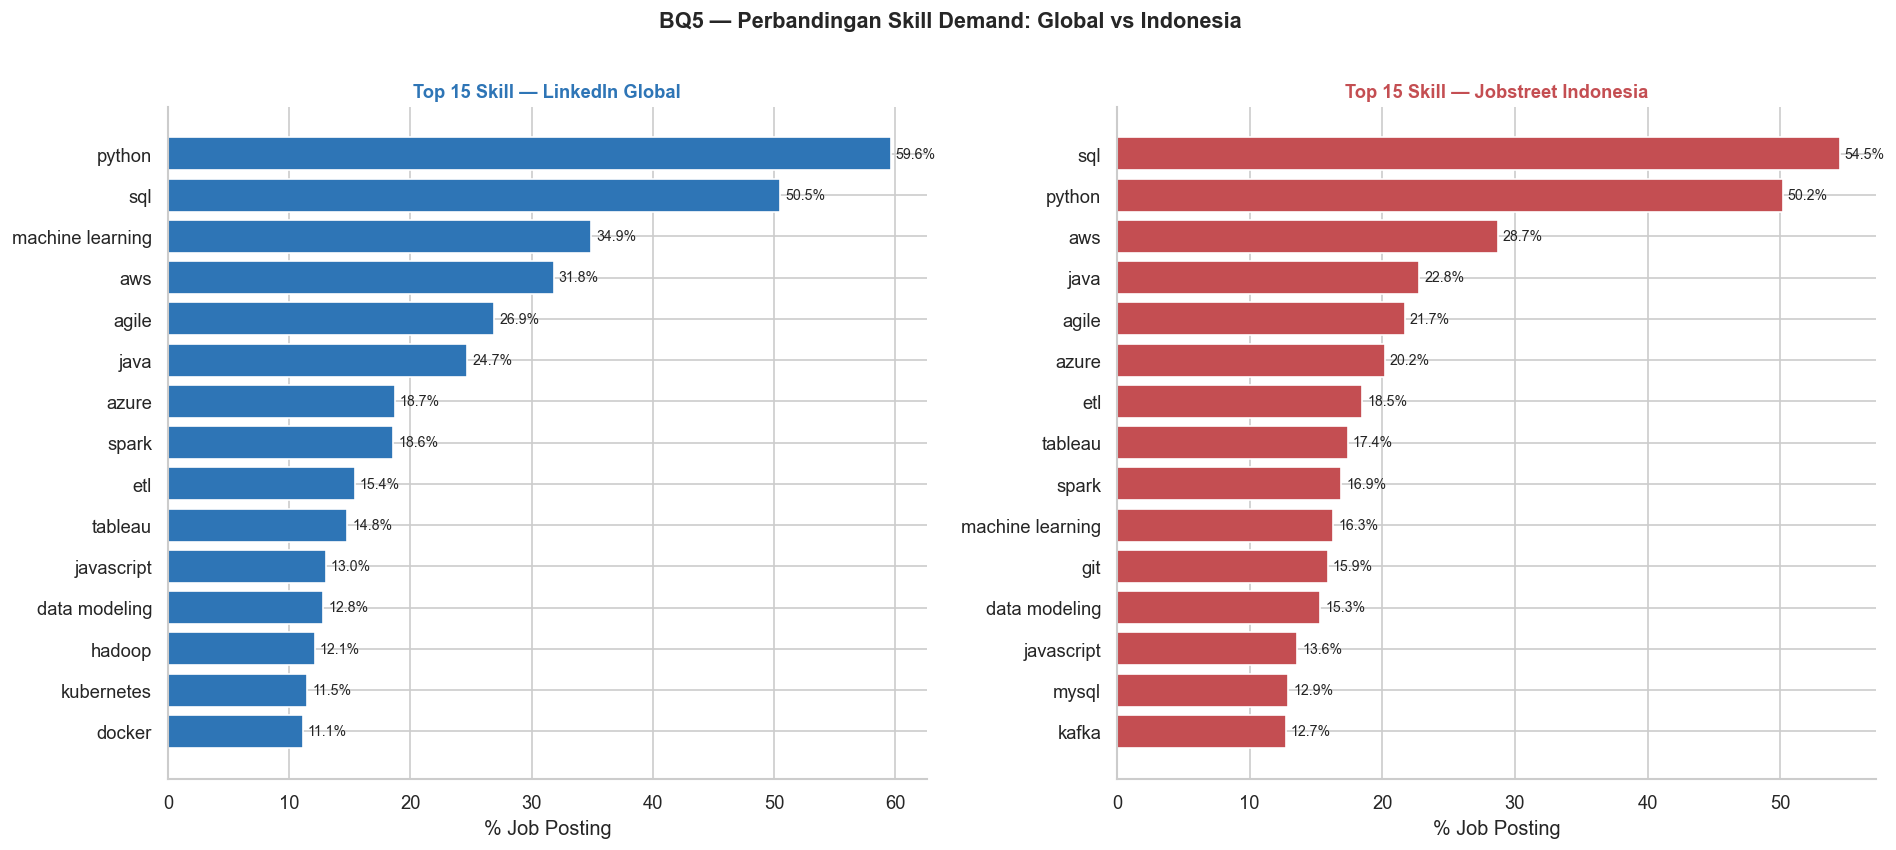

Skill HANYA di top Indonesia (tidak di top Global): {'mysql', 'kafka', 'git'}
Skill HANYA di top Global (tidak di top Indonesia): {'kubernetes', 'hadoop', 'docker'}


In [36]:
df_global = df[df['source'] == 'Global']
df_indo   = df[df['source'] == 'Indonesia (Jobstreet)']

top_global = get_skill_counts(df_global, top_n=15)
top_indo   = get_skill_counts(df_indo,   top_n=15)

# Normalisasi ke persentase
top_global['pct'] = (top_global['count'] / len(df_global) * 100).round(1)
top_indo['pct']   = (top_indo['count']   / len(df_indo)   * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

dg = top_global.sort_values('pct')
bars = axes[0].barh(dg['skill'], dg['pct'], color='#2E75B6', edgecolor='white')
axes[0].bar_label(bars, fmt='%.1f%%', padding=3, fontsize=8.5)
axes[0].set_title('Top 15 Skill — LinkedIn Global', fontsize=11, fontweight='bold', color='#2E75B6')
axes[0].set_xlabel('% Job Posting')
axes[0].spines[['top', 'right']].set_visible(False)

di = top_indo.sort_values('pct')
bars2 = axes[1].barh(di['skill'], di['pct'], color='#C44E52', edgecolor='white')
axes[1].bar_label(bars2, fmt='%.1f%%', padding=3, fontsize=8.5)
axes[1].set_title('Top 15 Skill — Jobstreet Indonesia', fontsize=11, fontweight='bold', color='#C44E52')
axes[1].set_xlabel('% Job Posting')
axes[1].spines[['top', 'right']].set_visible(False)

plt.suptitle('BQ5 — Perbandingan Skill Demand: Global vs Indonesia',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plot_bq5_global_vs_indo.png', bbox_inches='tight', dpi=150)
plt.show()

# Skill unik per sumber
global_set = set(top_global['skill'])
indo_set   = set(top_indo['skill'])
print('Skill HANYA di top Indonesia (tidak di top Global):', indo_set - global_set)
print('Skill HANYA di top Global (tidak di top Indonesia):', global_set - indo_set)

# Pertanyaan Bisnis 6: 
**Berapa rata-rata jumlah skill yang dibutuhkan per job posting per role?**

In [23]:
# Hitung jumlah skill per baris
df['skill_count'] = df['cleaned_skills'].apply(lambda x: len(parse_skills(x)))

print('=== Statistik Jumlah Skill per Job Posting (Keseluruhan) ===')
print(df['skill_count'].describe().round(2))
print()

complexity = df.groupby('job_category')['skill_count'].agg(['mean','median','min','max','std'])
complexity.columns = ['Rata-rata', 'Median', 'Min', 'Max', 'Std Dev']
complexity = complexity.reindex(ROLES_ORDER).round(2)
print('=== Jumlah Skill per Role ===')
print(complexity)

=== Statistik Jumlah Skill per Job Posting (Keseluruhan) ===
count    8644.00
mean        9.16
std         7.21
min         1.00
25%         4.00
50%         7.00
75%        12.00
max        70.00
Name: skill_count, dtype: float64

=== Jumlah Skill per Role ===
                                Rata-rata  Median  Min  Max  Std Dev
job_category                                                        
Data Engineer                        8.02     7.0    1   35     4.49
Data Analyst                         4.23     4.0    1   31     2.75
Backend Developer                   15.42    14.0    1   70     9.10
AI / Machine Learning Engineer       7.13     7.0    1   25     3.79
Data Scientist                       5.99     5.0    1   29     3.49
Fullstack Developer                 16.87    16.0    1   63     7.72
Frontend Developer                  17.99    17.0    1   61     9.34


**Insight Analisis Densitas Kebutuhan Skill (Skill Density Analysis):**

Tingkat Kompleksitas Rumpun Web Developer: Berdasarkan data statistik deskriptif, Frontend Developer (Rata-rata: ~17.99 skill) dan Fullstack Developer (Rata-rata: ~16.87 skill) memiliki tuntutan variasi kompetensi tertinggi per lowongan pekerjaan. Hal ini sangat logis mengingat ekosistem web modern menuntut penguasaan styling, manajemen state, pengujian (testing), optimasi performa client-side, hingga pemahaman integrasi API.

Tingkat Fokus Rumpun Data Science: Sebaliknya, Data Scientist memiliki rata-rata jumlah skill terendah per postings (Rata-rata: ~5.99 skill). Temuan ini mengindikasikan bahwa kualifikasi Data Scientist di industri cenderung lebih terfokus mendalam pada beberapa kapabilitas inti yang krusial (seperti Statistika, Pemodelan Machine Learning, dan Python) daripada penguasaan puluhan tools yang bersifat generalis.

# Data Dictionary

In [37]:
dd = pd.DataFrame([
    # Dataset asal
    {'Dataset':'df1 – job_postings.csv (Kaggle)',  'Kolom':'job_link',         'Tipe':'string',  'Deskripsi':'URL unik job posting LinkedIn, foreign key join dengan df2'},
    {'Dataset':'df1',                               'Kolom':'job_title',        'Tipe':'string',  'Deskripsi':'Judul pekerjaan sesuai posting LinkedIn'},
    {'Dataset':'df1',                               'Kolom':'job_level',        'Tipe':'string',  'Deskripsi':'Level pengalaman (Entry/Mid/Senior/Executive)'},
    {'Dataset':'df1',                               'Kolom':'job_type',         'Tipe':'string',  'Deskripsi':'Tipe pekerjaan (Full-time/Part-time/Contract/Remote)'},
    {'Dataset':'df1',                               'Kolom':'search_country',   'Tipe':'string',  'Deskripsi':'Negara asal pencarian — dataset ini bersifat global'},
    {'Dataset':'df2 – job_skills.csv (Kaggle)',     'Kolom':'job_link',         'Tipe':'string',  'Deskripsi':'Foreign key untuk join dengan df1'},
    {'Dataset':'df2',                               'Kolom':'job_skills',       'Tipe':'string',  'Deskripsi':'Raw string skill dari deskripsi job posting LinkedIn'},
    {'Dataset':'df3 – dataset_jobstreet.csv',       'Kolom':'Judul_Pekerjaan',  'Tipe':'string',  'Deskripsi':'Judul pekerjaan dari Jobstreet Indonesia'},
    {'Dataset':'df3',                               'Kolom':'Kualifikasi_Keterampilan','Tipe':'string','Deskripsi':'Skill yang dibutuhkan (format teks bebas dari Jobstreet)'},
    {'Dataset':'df3',                               'Kolom':'Gaji',             'Tipe':'string',  'Deskripsi':'Rentang gaji yang ditawarkan (banyak nilai kosong)'},
    {'Dataset':'df4 – Job Desc 2025 (Kaggle)',      'Kolom':'job_title',        'Tipe':'string',  'Deskripsi':'Judul pekerjaan — dataset augmentasi untuk developer roles'},
    {'Dataset':'df4',                               'Kolom':'job_skills',       'Tipe':'string',  'Deskripsi':'Skill dari deskripsi job — dipakai untuk Backend/Frontend/Fullstack'},
    {'Dataset':'df5 – LinkedIn SWE Jobs (Kaggle)', 'Kolom':'job_title',        'Tipe':'string',  'Deskripsi':'Judul pekerjaan — dataset augmentasi software engineering'},
    {'Dataset':'df5',                               'Kolom':'job_skills',       'Tipe':'string',  'Deskripsi':'Skill dari posting software engineering LinkedIn'},
    # Dataset final
    {'Dataset':'bismillah_fix_dataset.csv (FINAL)','Kolom':'job_title',        'Tipe':'string',  'Deskripsi':'Judul pekerjaan — hasil gabungan 4 dataset sumber'},
    {'Dataset':'bismillah_fix_dataset.csv (FINAL)','Kolom':'job_skills',       'Tipe':'string',  'Deskripsi':'Raw skill string sebelum ekstraksi'},
    {'Dataset':'bismillah_fix_dataset.csv (FINAL)','Kolom':'cleaned_skills',   'Tipe':'string',  'Deskripsi':'Skill bersih hasil ekstraksi dari master_skills_list, format CSV string'},
    {'Dataset':'bismillah_fix_dataset.csv (FINAL)','Kolom':'job_category',     'Tipe':'string',  'Deskripsi':'Kategori profesi hasil rule-based keyword mapping dari job_title (7 kategori)'},
    # Kolom turunan EDA
    {'Dataset':'(EDA derived)',                     'Kolom':'skill_count',      'Tipe':'integer', 'Deskripsi':'Jumlah skill per job posting — dihitung dari cleaned_skills'},
    {'Dataset':'(EDA derived)',                     'Kolom':'source',           'Tipe':'string',  'Deskripsi':'Sumber data: Global (LinkedIn/Kaggle) atau Indonesia (Jobstreet)'},
    # Output EDA
    {'Dataset':'knowledge_base_skills.csv (OUTPUT)','Kolom':'job_category',    'Tipe':'string',  'Deskripsi':'Nama kategori profesi'},
    {'Dataset':'knowledge_base_skills.csv (OUTPUT)','Kolom':'skill',           'Tipe':'string',  'Deskripsi':'Nama skill'},
    {'Dataset':'knowledge_base_skills.csv (OUTPUT)','Kolom':'frequency',       'Tipe':'integer', 'Deskripsi':'Jumlah kemunculan skill di job posting untuk role tersebut'},
    {'Dataset':'knowledge_base_skills.csv (OUTPUT)','Kolom':'rank_in_role',    'Tipe':'integer', 'Deskripsi':'Peringkat skill berdasarkan frekuensi dalam role'},
    {'Dataset':'knowledge_base_skills.csv (OUTPUT)','Kolom':'tier',            'Tipe':'string',  'Deskripsi':'Tingkat urgensi: Critical (rank 1-3), Important (4-6), Supplementary (7-10)'},
])

pd.set_option('display.max_colwidth', 80)
display(dd)
dd.to_csv('data_dictionary.csv', index=False)
print('Data dictionary disimpan ke data_dictionary.csv!')

,Dataset,Kolom,Tipe,Deskripsi
0,df1 – job_postings.csv (Kaggle),job_link,string,"URL unik job posting LinkedIn, foreign key join dengan df2"
1,df1,job_title,string,Judul pekerjaan sesuai posting LinkedIn
2,df1,job_level,string,Level pengalaman (Entry/Mid/Senior/Executive)
3,df1,job_type,string,Tipe pekerjaan (Full-time/Part-time/Contract/Remote)
4,df1,search_country,string,Negara asal pencarian — dataset ini bersifat global
5,df2 – job_skills.csv (Kaggle),job_link,string,Foreign key untuk join dengan df1
6,df2,job_skills,string,Raw string skill dari deskripsi job posting LinkedIn
7,df3 – dataset_jobstreet.csv,Judul_Pekerjaan,string,Judul pekerjaan dari Jobstreet Indonesia
8,df3,Kualifikasi_Keterampilan,string,Skill yang dibutuhkan (format teks bebas dari Jobstreet)
9,df3,Gaji,string,Rentang gaji yang ditawarkan (banyak nilai kosong)


Data dictionary disimpan ke data_dictionary.csv!


In [38]:
print('=' * 65)
print('RINGKASAN EDA — SKILL GAP ANALYZER')
print('=' * 65)
print(f"""
Dataset Summary:
  Total job posting final  : {len(df):,}
  Jumlah role              : {df['job_category'].nunique()} role
  Total skill unik         : {total_unique_skills:,}
  Sumber data              : 4 dataset (2 Kaggle + 1 Jobstreet + 1 Kaggle SWE)

Distribusi per role:
""")
for role in ROLES_ORDER:
    n = len(df[df['job_category'] == role])
    bar = '█' * (n // 100)
    print(f"  {role:<35} {n:>5,}  {bar}")

print(f"""
Business Questions:
  BQ1 — Top skill demand       : plot_bq1_top30_skills.png
  BQ2 — Skill per role         : plot_bq2_heatmap.png
                                  knowledge_base_skills.csv  ← untuk AI Engineer
  BQ3 — Skill co-occurrence    : plot_bq3_cooccurrence.png
  BQ4 — Distribusi & augmentasi: plot_bq4_distribusi_role.png
                                  plot_bq4_augmentasi.png
  BQ5 — Global vs Indonesia    : plot_bq5_global_vs_indo.png
  BQ6 — Kompleksitas skill     : plot_bq6_skill_complexity.png

Output Files:
  bismillah_fix_dataset.csv    : Dataset final siap training model
  knowledge_base_skills.csv    : Knowledge base skill per role + tier
  data_dictionary.csv          : Dokumentasi kolom seluruh dataset
""")
print('\n📌 Catatan untuk AI Engineer:')
print('  knowledge_base_skills.csv berisi tier Critical/Important/Supplementary')
print('  per role — langsung bisa dipakai untuk logika scoring model.')
print()
print('📌 Catatan penting (temuan EDA):')
print('  3 role developer awalnya underrepresented (Backend=311, Fullstack=138, Frontend=36).')
print('  Dilakukan augmentasi dengan 2 dataset tambahan sehingga semua role ≥ 285 entri.')
print('  Ini memastikan knowledge base yang dibangun cukup representatif untuk semua role.')

RINGKASAN EDA — SKILL GAP ANALYZER

Dataset Summary:
  Total job posting final  : 8,644
  Jumlah role              : 7 role
  Total skill unik         : 6,820
  Sumber data              : 4 dataset (2 Kaggle + 1 Jobstreet + 1 Kaggle SWE)

Distribusi per role:

  Data Engineer                       2,486  ████████████████████████
  Data Analyst                        1,807  ██████████████████
  Backend Developer                   1,206  ████████████
  AI / Machine Learning Engineer      1,032  ██████████
  Data Scientist                        948  █████████
  Fullstack Developer                   880  ████████
  Frontend Developer                    285  ██

Business Questions:
  BQ1 — Top skill demand       : plot_bq1_top30_skills.png
  BQ2 — Skill per role         : plot_bq2_heatmap.png
                                  knowledge_base_skills.csv  ← untuk AI Engineer
  BQ3 — Skill co-occurrence    : plot_bq3_cooccurrence.png
  BQ4 — Distribusi & augmentasi: plot_bq4_distribusi_role.pn